In [54]:
# from urllib.request import urlopen
from bs4 import BeautifulSoup
from bs4 import SoupStrainer

from datetime import datetime

from fuzzywuzzy import fuzz
from fuzzywuzzy import process

# import urllib.request
import wikipedia
import pandas as pd

import requests
import re

import lxml

import time
import math

import numpy as np

import itertools

import matplotlib.pyplot as plt

In [55]:
omdb_api_key = '9a143b31'

## Functions

In [56]:
def get_section(title, href, section_name):
    
    try:
        section_results = wikipedia.page("'" + title + "'").section(section_name)
        if section_results is None:
            section_results = wikipedia.page("\"" + title + "\"").section(section_name)
            if section_results is None:
                section_results = wikipedia.page(href).section(section_name)
    except:
        section_results = None
    
    return section_results

In [57]:
def collect_people_info_from_wiki_data(x, col_name, to_replace):
    if type(x[col_name]) == str:        
        clean_formatted_string = re.sub('\[(.*?)\]|\((.*?)\)', '', x[col_name].replace(to_replace, ''))
        return [y for y in clean_formatted_string.split('\n') if y != '']
    else:
        return None

In [58]:
def collect_financial_info_from_wiki_data(x, col_name, str_to_avoid = None):
    if type(x[col_name]) == str:
        if str_to_avoid:
            if str_to_avoid in x[col_name].lower():
                return None
            else:
                return handle_text_based_units(
                    re.sub(r'(.*?)\$|\[(.*?)\]|\((.*?)\)', '', x[col_name])
                )
        else:
            return handle_text_based_units(
                re.sub(r'(.*?)\$|\[(.*?)\]|\((.*?)\)', '', x[col_name])
            )
    else:
        return None

In [59]:
def handle_text_based_units(value):
    
    # try except will return None for cases not covered here - two numbers
    try:
        value = value.replace(' ','').replace(',','')
        multiplier = 1
        
        if 'billion' in value.lower():
            value = value.replace('billion','')
            multiplier = 10 ** 9
        elif 'million' in value.lower():
            value = value.replace('million','')
            multiplier = 10 ** 6
            
        if '–' in value:
            ind = value.index('–')
            start, end = float(value[:ind]), float(value[ind+1:])
            return np.mean([start, end]) * multiplier
        elif '-' in value:
            ind = value.index('-')
            start, end = float(value[:ind]), float(value[ind+1:])
            return np.mean([start, end]) * multiplier
        else:
            return float(value) * multiplier        
    except:
        return None

In [60]:
def choose_plot_feature_to_use(x):
    
    plot_features = ['plot','premise','synopsis','omdb_plot']
    
    options = []
    
    for plot_feature in plot_features:
        if x[plot_feature] is not None and x[plot_feature] != 'N/A':
            options.append((plot_feature, len(x[plot_feature])))
    
    plot_features_sorted = sorted(options, key = lambda x: -x[1])
    
    if len(plot_features_sorted) > 0:    
        return x[plot_features_sorted[0][0]]
    else:
        return None

In [61]:
def has_actor_in_plot(x):
    if x['actors_to_use'] and x['plot_parenthetical']:
        combos = itertools.product(x['actors_to_use'], x['plot_parenthetical'])
        plot_parenthetical_with_scores = [
            (y[1], fuzz.ratio(y[0], y[1])) for y in combos if fuzz.ratio(y[0], y[1]) > 65
        ]
        if plot_parenthetical_with_scores:
            return plot_parenthetical_with_scores
        else:
            return None
    else:
        return None 

In [62]:
def replace_in_plot_actor_reference(x):
    
    new_plot = x['chosen_plot_feature']
    
    if isinstance(x['plot_parenthetical_fuzzy_scores'], list):
        for fuzzy_match in x['plot_parenthetical_fuzzy_scores']:
            new_plot = new_plot.replace(f'({fuzzy_match[0]})', '')
        return new_plot
    else:
        return new_plot

## Scraping

In [63]:
session = requests.Session()

records = []

# 50 years
for year in range(1973, 2024):
    page_response = session.get(f'https://en.wikipedia.org/wiki/List_of_American_films_of_{year}')
    if page_response.status_code == 200:
        soup = BeautifulSoup(page_response.content, 'lxml')
        for tag in soup.find_all('a'):
            if tag.parent.name == 'i' and tag.parent.parent.name == 'td':
                records.append({'year':year, 'href':tag['href'].replace('/wiki/',''), 'title':tag['title']})

In [64]:
# session = requests.Session()

# records = []

# # 50 years
# for year in range(1973, 2024):
#     page_response = session.get(f'https://en.wikipedia.org/wiki/List_of_American_films_of_{year}')
#     if page_response.status_code == 200:
#         soup = BeautifulSoup(page_response.content, 'lxml')
#         for tag in soup.find_all('a'):
#             if tag.parent.name == 'i' and tag.parent.parent.name == 'td':
#                 # ensure that duplicate records not grabbed if seq
#                 if 'sequel' not in tag.parent.parent.text:
#                     records.append({'year':year, 'href':tag['href'].replace('/wiki/',''), 'title':tag['title']})

In [65]:
# len(records)

In [66]:
[x for x in records if x['href'] == 'The_Silence_of_the_Lambs_(film)']

[{'year': 1991,
  'href': 'The_Silence_of_the_Lambs_(film)',
  'title': 'The Silence of the Lambs (film)'},
 {'year': 2001,
  'href': 'The_Silence_of_the_Lambs_(film)',
  'title': 'The Silence of the Lambs (film)'},
 {'year': 2002,
  'href': 'The_Silence_of_the_Lambs_(film)',
  'title': 'The Silence of the Lambs (film)'}]

In [67]:
[x for x in records if x['title'] == 'Rocky']

[{'year': 1976, 'href': 'Rocky', 'title': 'Rocky'},
 {'year': 1979, 'href': 'Rocky', 'title': 'Rocky'},
 {'year': 1982, 'href': 'Rocky', 'title': 'Rocky'},
 {'year': 1985, 'href': 'Rocky', 'title': 'Rocky'},
 {'year': 1990, 'href': 'Rocky', 'title': 'Rocky'}]

In [68]:
[x for x in records if x['title'] == 'Star Wars']

[{'year': 1977, 'href': 'Star_Wars', 'title': 'Star Wars'},
 {'year': 1980, 'href': 'Star_Wars', 'title': 'Star Wars'},
 {'year': 1983, 'href': 'Star_Wars', 'title': 'Star Wars'},
 {'year': 1987, 'href': 'Star_Wars', 'title': 'Star Wars'}]

In [69]:
[x for x in records if x['href'] == 'Superman_(1978_film)']

[{'year': 1978,
  'href': 'Superman_(1978_film)',
  'title': 'Superman (1978 film)'},
 {'year': 1980,
  'href': 'Superman_(1978_film)',
  'title': 'Superman (1978 film)'}]

In [70]:
start = time.time()

for ind, item in enumerate(records):
    
    if ind > 0 and ind % 125 == 0:
        print(f'{ind} out of {len(records)}, took {round((time.time() - start) / 60)} minutes')
        start = time.time()
    
    if 'page does not exist' not in item['title']:

        ## get plain text content from plot or plot related sections
        title = item['title']
        href = item['href']

        item['plot'] = get_section(title, href, 'Plot')
        if item['plot'] is None:
            item['premise'] = get_section(title, href, 'Premise')
            if item['premise'] is None:
                item['synopsis'] = get_section(title, href, 'Synopsis')
                if item['synopsis'] is None:
                    item['synopsis'] = get_section(title, href, 'Plot synopsis')
            else:
                item['synopsis'] = None
        else:
            item['premise'], item['synopsis'] = None, None
                    
        ## get budget and box office numbers from right hand infobox table
        page_response = session.get(f"https://en.wikipedia.org/wiki/{item['href']}")
        if page_response.status_code == 200:
            only_infobox_tables = SoupStrainer('table', {'class':'infobox vevent'})
            page_soup = BeautifulSoup(page_response.content, 'lxml', parse_only = only_infobox_tables)
            infobox = page_soup.find('table', {'class':'infobox vevent'})
            if infobox:
                for tr in infobox.find_all('tr'):
                                            
                    if 'directed by' in tr.text.lower():
                        item['directed_by'] = tr.text
                    if 'screenplay by' in tr.text.lower():
                        item['screenplay_by'] = tr.text
                    if 'written by' in tr.text.lower():
                        item['written_by'] = tr.text
                    if 'based on' in tr.text.lower():
                        item['based_on'] = tr.text                        
                    if 'starring' in tr.text.lower():
                        item['starring'] = tr.text
                    if 'budget' in tr.text.lower():
                        item['budget'] = tr.text
                    if 'box office' in tr.text.lower():
                        item['box_office'] = tr.text
                  
                # assign None if no budget or box office values at end of iteration
                if not item.get('directed_by'):
                    item['directed_by'] = None
                if not item.get('screenplay_by'):
                    item['screenplay_by'] = None
                if not item.get('written_by'):
                    item['written_by'] = None
                if not item.get('based_on'):
                    item['based_on'] = None
                if not item.get('starring'):
                    item['starring'] = None
                if not item.get('budget'):
                    item['budget'] = None
                if not item.get('box_office'):
                    item['box_office'] = None
            else:
                item['directed_by'], item['screenplay_by'], item ['written_by'] = None, None, None
                item['based_on'] = None
                item['starring'], item['budget'], item['box_office'] = None, None, None
    else:
        item['plot'], item['premise'], item['synopsis'] = None, None, None
        item['directed_by'], item['screenplay_by'], item ['written_by'] = None, None, None
        item['based_on'] = None
        item['starring'], item['budget'], item['box_office'] = None, None, None

    ## get JSON response from OMDb API
    pattern = r" \([0-9]{4} film\)| \(film\)"
    search_title = re.sub(pattern, '', item['title']).lower().replace(' ','+')
    
    omdb_response = session.get(
        f"http://www.omdbapi.com/?apikey={omdb_api_key}&t={search_title}&y={item['year']}&plot=full"
    )

    if omdb_response.status_code == 200:
        item['omdb_response'] = omdb_response.json()
    else:
        item['omdb_response'] = None

/opt/homebrew/Caskroom/miniforge/base/envs/mids/lib/python3.11/site-packages/wikipedia/wikipedia.py:389: GuessedAtParserWarning: No parser was explicitly specified, so I'm using the best available HTML parser for this system ("lxml"). This usually isn't a problem, but if you run this code on another system, or in a different virtual environment, it may use a different parser and behave differently.

The code that caused this warning is on line 389 of the file /opt/homebrew/Caskroom/miniforge/base/envs/mids/lib/python3.11/site-packages/wikipedia/wikipedia.py. To get rid of this warning, pass the additional argument 'features="lxml"' to the BeautifulSoup constructor.

  lis = BeautifulSoup(html).find_all('li')


125 out of 13255, took 6 minutes
250 out of 13255, took 5 minutes
375 out of 13255, took 5 minutes
500 out of 13255, took 5 minutes
625 out of 13255, took 5 minutes
750 out of 13255, took 7 minutes
875 out of 13255, took 5 minutes
1000 out of 13255, took 5 minutes
1125 out of 13255, took 6 minutes
1250 out of 13255, took 6 minutes
1375 out of 13255, took 6 minutes
1500 out of 13255, took 5 minutes
1625 out of 13255, took 5 minutes
1750 out of 13255, took 6 minutes
1875 out of 13255, took 5 minutes
2000 out of 13255, took 6 minutes
2125 out of 13255, took 5 minutes
2250 out of 13255, took 5 minutes
2375 out of 13255, took 6 minutes
2500 out of 13255, took 5 minutes
2625 out of 13255, took 5 minutes
2750 out of 13255, took 7 minutes
2875 out of 13255, took 6 minutes
3000 out of 13255, took 5 minutes
3125 out of 13255, took 6 minutes
3250 out of 13255, took 5 minutes
3375 out of 13255, took 5 minutes
3500 out of 13255, took 5 minutes
3625 out of 13255, took 5 minutes
3750 out of 13255, to

In [71]:
df = pd.DataFrame(records)
df.shape

(13255, 14)

In [72]:
df = pd.DataFrame(records)
df.drop_duplicates(subset = [x for x in df.columns if x != 'omdb_response'], inplace = True)
df.shape

(12788, 14)

In [73]:
df = pd.DataFrame(records)
df.drop_duplicates(subset = [x for x in df.columns if x not in {'year','omdb_response'}], inplace = True)
df.shape

(12465, 14)

In [74]:
### save data to csv
df.to_csv('Scraped movie data without any preprocesing.csv', index = False)

In [75]:
df[df.title.isin(['Rocky','Star Wars','Superman (1978 film)'])]

,year,href,title,plot,premise,synopsis,directed_by,screenplay_by,based_on,starring,box_office,written_by,budget,omdb_response
637,1976,Rocky,Rocky,"In 1975, the heavyweight boxing world champion...",None,None,Directed byJohn G. Avildsen,None,None,Starring\nSylvester Stallone\nTalia Shire\nBur...,Box office$225 million [2],Written bySylvester Stallone,"Budget$960,000","{'Title': 'Rocky', 'Year': '1976', 'Rated': 'P..."
823,1977,Star_Wars,Star Wars,None,The Star Wars franchise depicts the adventures...,None,None,None,None,None,None,None,None,{'Title': 'Star Wars: Episode IV - A New Hope'...
968,1978,Superman_(1978_film),Superman (1978 film),"On the planet Krypton, Jor-El of the Kryptonia...",None,None,Directed byRichard Donner,Screenplay by\nMario Puzo\nDavid Newman\nLesli...,Based onSupermanby Jerry Siegel Joe Shuster,Starring\nMarlon Brando\nGene Hackman\nChristo...,Box office$300.5 million[6],None,Budget$55 million[6],"{'Title': 'Superman', 'Year': '1978', 'Rated':..."


## Preprocessing after scraping

### Extract and clean OMBb response key-value pairs

In [78]:
df['omdb_title'] = df['omdb_response'].apply(lambda x: x.get('Title')) 
df['genres'] = df['omdb_response'].apply(lambda x: x.get('Genre','').split(','))
df['omdb_plot'] = df['omdb_response'].apply(lambda x: x.get('Plot'))

df['release_date'] = df['omdb_response'].apply(lambda x: x.get('Released'))
df['release_date'] = df['release_date'].apply(
    lambda x: datetime.strptime(x, '%d %b %Y') if isinstance(x, str) and len(x) == 11 else None
)

df['omdb_director'] = df['omdb_response'].apply(lambda x: x.get('Director',''))
df['omdb_director'] = df['omdb_director'].apply(lambda x: x.split(',') if x != 'N/A' else None)

df['omdb_writer'] = df['omdb_response'].apply(lambda x: x.get('Writer',''))
df['omdb_writer'] = df['omdb_writer'].apply(lambda x: x.split(',') if x != 'N/A' else None)

df['omdb_actors'] = df['omdb_response'].apply(lambda x: x.get('Actors',''))
df['omdb_actors'] = df['omdb_actors'].apply(lambda x: x.split(',') if x != 'N/A' else None)

df['imdb_score'] = df['omdb_response'].apply(lambda x: x.get('imdbRating'))
df['imdb_score'] = df['imdb_score'].apply(lambda x: float(x) if x != 'N/A' and x is not None else math.nan)

df['imdb_votes'] = df['omdb_response'].apply(lambda x: x.get('imdbVotes'))
df['imdb_votes'] = df['imdb_votes'].apply(
    lambda x: int(x.replace(',','')) if x != 'N/A' and x is not None else math.nan
)

df['rotten_tomatoes_score'] = df['omdb_response'].apply(
    lambda x: [y.get('Value') for y in x.get('Ratings') if 'Rotten Tomatoes' in y.values()] if x.get('Ratings') else None
)

df['rotten_tomatoes_score'] = df['rotten_tomatoes_score'].apply(
    lambda x: int(x[0].replace('%','')) if x != [] and x is not None else math.nan
)

df['metacritic_score'] = df['omdb_response'].apply(
    lambda x: [y.get('Value') for y in x.get('Ratings') if 'Metacritic' in y.values()] if x.get('Ratings') else None
)

df['metacritic_score'] = df['metacritic_score'].apply(
    lambda x: int(x[0].replace('/100','')) if x != [] and x is not None else math.nan
)

### Clean people data from Wikipedia

In [79]:
df['directed_by_clean'] = df.apply(
    collect_people_info_from_wiki_data,
    axis = 1, 
    args = ('directed_by','Directed by')
)

df['screenplay_by_clean'] = df.apply(
    collect_people_info_from_wiki_data,
    axis = 1, 
    args = ('screenplay_by','Screenplay by')
)

df['written_by_clean'] = df.apply(
    collect_people_info_from_wiki_data,
    axis = 1, 
    args = ('written_by','Written by')
)

df['starring_clean'] = df.apply(
    collect_people_info_from_wiki_data,
    axis = 1, 
    args = ('starring','Starring')
)

### Based on feature engineering

In [80]:
df[
    (~df['based_on'].isna()) &
    (
        (df['based_on'].str.contains('story')) |
        ((df['based_on'].str.contains('book')) & (df['based_on'].str.contains('comic') == False)) |
        (df['based_on'].str.contains('novel')) |
        (df['based_on'].str.contains('play')) |
        (df['based_on'].str.contains('TV'))
    )
]['based_on'].shape

(273,)

Above data too thin to work with... Also may be basedo on story / book / etc. but not state these words in the "Based on" string

In [81]:
df['based_on_binary'] = df['based_on'].apply(
    lambda x: True if x else False
)

df['based_on_binary_characters'] = df.apply(
    lambda x: None if not x['based_on_binary'] else True if 'characters' in x['based_on'].lower() else False,
    axis = 1
)

df['based_on_binary_comic_books'] = df.apply(
    lambda x: None if not x['based_on_binary']
        else True if 'comic' in x['based_on'].lower()
        else True if 'dc' in x['based_on'].lower()
        else True if 'marvel' in x['based_on'].lower()
        else True if 'stan lee' in x['based_on'].lower()
        else True if 'jack kirby' in x['based_on'].lower()
        else True if 'steve ditko' in x['based_on'].lower()
        else False,
    axis = 1    
)

### Clean financial data from Wikipedia

In [82]:
df['box_office_clean'] = df.apply(
    collect_financial_info_from_wiki_data,
    axis = 1,
    args = ('box_office', 'rentals')
)

df['budget_clean'] = df.apply(
    collect_financial_info_from_wiki_data,
    axis = 1,
    args = ('budget', None)
)

### Choose which features to use among multiple options

In [83]:
df['chosen_plot_feature'] = df.apply(
    lambda x: choose_plot_feature_to_use(x),
    axis = 1
)

In [84]:
df['writers_to_use'] = df.apply(
    lambda x: x['omdb_writer'] if x['omdb_writer'] != [] and x['omdb_writer'] is not None 
        else x['written_by_clean'] if x['written_by_clean'] is not None
        else x['screenplay_by_clean'] if x['screenplay_by_clean'] is not None
        else None, 
    axis = 1
)

In [85]:
df['actors_to_use'] = df.apply(
    lambda x: x['omdb_actors'] if x['omdb_actors'] != [] and x['omdb_actors'] is not None 
        else x['starring_clean'], 
    axis = 1
)

### Examine possible actor names in plot

In [86]:
df['chosen_plot_feature'].fillna('', inplace = True)

In [87]:
df['plot_parenthetical'] = df['chosen_plot_feature'].apply(
    lambda x: [y.replace('(','').replace(')','') for y in re.findall('\(.*?\)', x)]
)

In [88]:
df['num_parentheticals'] = df['plot_parenthetical'].apply(len)

df[
#     ~((df['plot'].isna()) & (df['premise'].isna()) & (df['synopsis'].isna())) &
    (~df['box_office_clean'].isna()) & (~df['budget_clean'].isna()) &
    (~df['rotten_tomatoes_score'].isna()) &
    (df['num_parentheticals'] > 0)
][['plot_parenthetical','starring_clean','omdb_actors']].sample(10)

,plot_parenthetical,starring_clean,omdb_actors
4474,"[as they always are given in pairs, a warehous...","[Jean-Claude Van Damme, Lance Henriksen, Yancy...","[Jean-Claude Van Damme, Lance Henriksen, Yan..."
6350,"[Smith, Girlina, Paula Jai Parker, Dave Chappe...","[Tommy Davidson, Jada Pinkett Smith, Dave Chap...","[Jada Pinkett Smith, Tommy Davidson, Duane M..."
2398,[who at the last minute decides not to join th...,"[Blythe Danner, Bob Dishy, Judith Ivey, Jonath...","[Blythe Danner, Jonathan Silverman, Stacey G..."
592,[MGM],"[Robert De Niro, Tony Curtis, Robert Mitchum, ...","[Robert De Niro, Tony Curtis, Robert Mitchum]"
2852,"[the women know each other, C.D.'s first name]","[Steve Martin, Daryl Hannah, Shelley Duvall, R...","[Steve Martin, Daryl Hannah, Rick Rossovich]"
4625,"[""no worries"" in Swahili]","[Jonathan Taylor Thomas, Matthew Broderick, Ja...","[Matthew Broderick, Jeremy Irons, James Earl..."
6297,[a mispronunciation of wizard],"[E. G. Daily, Tara Charendoff, Christine Cavan...","[Elizabeth Daily, Christine Cavanaugh, Kath ..."
7965,[Chrishelle's pipe],"[Cedric the Entertainer, Bow Wow, Vanessa Will...","[Cedric the Entertainer, Shannon Elizabeth, ..."
4055,[Italian for courage or bravery],"[Steven Seagal, William Forsythe, Jerry Orbach...","[Steven Seagal, William Forsythe, Jerry Orbach]"
1873,"[near Crescent, Oklahoma]","[Meryl Streep, Kurt Russell, Cher]","[Meryl Streep, Kurt Russell, Cher]"


In [89]:
df['plot_parenthetical_fuzzy_scores'] = df.apply(
    lambda x: has_actor_in_plot(x),
    axis = 1
)

In [90]:
df['new_plot'] = df.apply(
    lambda x: replace_in_plot_actor_reference(x),
    axis = 1
)

In [91]:
df[
#     ~((df['plot'].isna()) & (df['premise'].isna()) & (df['synopsis'].isna())) &
    (~df['box_office_clean'].isna()) & (~df['budget_clean'].isna()) &
    (~df['rotten_tomatoes_score'].isna()) &
    (df['num_parentheticals'] > 0) &
    ~df['plot_parenthetical_fuzzy_scores'].isna()
][['plot_parenthetical','plot_parenthetical_fuzzy_scores','chosen_plot_feature','new_plot']]

,plot_parenthetical,plot_parenthetical_fuzzy_scores,chosen_plot_feature,new_plot
86,"[Jack Nicholson, Otis Young, Randy Quaid, a fi...","[(Jack Nicholson, 100), (Randy Quaid, 96), (Ot...","On Saturday, December 15, 1973, Navy lifers Si...","On Saturday, December 15, 1973, Navy lifers Si..."
116,"[Steve McQueen, Dustin Hoffman, Woodrow Parfre...","[(Steve McQueen, 100), (Dustin Hoffman, 97)]","Henri Charrière (Steve McQueen), is a safecrac...","Henri Charrière , is a safecracker nicknamed ""..."
141,"[Woody Allen, played by Bartlett Robinson and ...","[(Woody Allen, 100), (Diane Keaton, 96), (John...",Miles Monroe (Woody Allen) is a jazz musician ...,Miles Monroe is a jazz musician and owner of ...
208,"[Dickinson, Skerritt, Robbie Lee, Susan Sennet...","[(Dickinson, 75), (Skerritt, 76)]","In Texas in 1932, after stopping her youngest ...","In Texas in 1932, after stopping her youngest ..."
248,"[Jack Lemmon, Susan Sarandon, Austin Pendleton...","[(Jack Lemmon, 100), (Walter Matthau, 97), (Su...","Chicago Examiner reporter Hildebrand ""Hildy"" J...","Chicago Examiner reporter Hildebrand ""Hildy"" J..."
...,...,...,...,...
12321,"[Emily Blunt, Jamie Dornan, Christopher Walken...","[(Emily Blunt, 100), (Jamie Dornan, 96), (Jon ...","In County Mayo, Ireland, two introverted misfi...","In County Mayo, Ireland, two introverted misfi..."
12457,"[Samuel L. Jackson, Chris Rock, Max Minghella]","[(Chris Rock, 100), (Samuel L. Jackson, 97), (...","Working in the shadow of his father, an esteem...","Working in the shadow of his father, an esteem..."
12477,"[Golden Globe nominee PIERCE BROSNAN, NICK CAN...","[(Tim Roth, 94)]",Even a federal maximum-security prison can't h...,Even a federal maximum-security prison can't h...
12531,[Damon],"[(Damon, 67)]","Stillwater, Oklahoma roughneck Bill Baker (Dam...","Stillwater, Oklahoma roughneck Bill Baker tra..."


### Writer feature engineering

In [92]:
# df['writers_to_use_type'] = df['writers_to_use'].apply(
#     lambda x: type(x)
# )

# df['writers_to_use_type'].value_counts()

In [93]:
# # keep truthy values in place since lists, otherwise take empty list
# df['writers_to_use'] = df['writers_to_use'].apply(
#     lambda x: x if x else []
# )

# df['writers_to_use_type'] = df['writers_to_use'].apply(
#     lambda x: type(x)
# )

# df['writers_to_use_type'].value_counts()

In [94]:
df_writers_by_release_date = df[['release_date','writers_to_use']].explode('writers_to_use')

### handle nulls and empty strings
df_writers_by_release_date.dropna(inplace = True)

blank_writers = df_writers_by_release_date[df_writers_by_release_date['writers_to_use'] == ''].index
df_writers_by_release_date.drop(blank_writers, inplace = True)

### handle leading and trailing spaces
df_writers_by_release_date['writers_to_use'] = df_writers_by_release_date['writers_to_use'].apply(
    lambda x: x.strip()
)

In [95]:
df_writers_by_release_date.sort_values(by = ['writers_to_use','release_date'], inplace = True)

df_writers_by_release_date['writers_nth_movie_entry_in_dataset'] = df_writers_by_release_date.groupby(
    'writers_to_use'
)['release_date'].rank(
    method = 'dense'
)

In [96]:
df_writers_first_movie = df_writers_by_release_date[
    df_writers_by_release_date['writers_nth_movie_entry_in_dataset'] == 1
]

writers_first_movie_set = {
    (x.strip(), y) for x,y in zip(df_writers_first_movie['writers_to_use'], df_writers_first_movie['release_date'])
}

In [97]:
df['all_writers_first_movie'] = df.apply(
    lambda x: None if x['writers_to_use'] == [] or x['writers_to_use'] is None
        else all([(writer, x['release_date']) in writers_first_movie_set for writer in x['writers_to_use']]),
    axis = 1
)

df['any_writers_first_movie'] = df.apply(
    lambda x: None if x['writers_to_use'] == [] or x['writers_to_use'] is None
        else any([(writer, x['release_date']) in writers_first_movie_set for writer in x['writers_to_use']]),
    axis = 1
)

In [98]:
# df[
#     df['all_writers_first_movie'] == True
# ].sample(7)[['title','year','release_date','writers_to_use']]

In [99]:
df_writers_by_release_date[df_writers_by_release_date['writers_to_use'] == 'M. Night Shyamalan']

,release_date,writers_to_use,writers_nth_movie_entry_in_dataset
4298,1993-09-15,M. Night Shyamalan,1.0
6347,1998-03-20,M. Night Shyamalan,2.0
6548,1999-08-06,M. Night Shyamalan,3.0
6561,1999-12-17,M. Night Shyamalan,4.0
6824,2000-11-22,M. Night Shyamalan,5.0
7138,2002-08-02,M. Night Shyamalan,6.0
8034,2004-07-30,M. Night Shyamalan,7.0
8420,2006-07-21,M. Night Shyamalan,8.0
8909,2008-06-13,M. Night Shyamalan,9.0
9662,2010-07-01,M. Night Shyamalan,10.0


In [100]:
df[df['title'] == 'Old (film)'][['title','year','writers_to_use','all_writers_first_movie']]

,title,year,writers_to_use,all_writers_first_movie
12522,Old (film),2021,"[M. Night Shyamalan, Pierre-Oscar Lévy, Fred...",False


### Data labels

In [101]:
df['roi'] = df.apply(
    lambda x: x['box_office_clean'] / x['budget_clean'] if x['box_office_clean'] is not None and x['budget_clean'] is not None
        else None,
    axis = 1
)

In [102]:
df['roi_binary'] = df['roi'].apply(
    lambda x: 1 if x > 1 else 0
)

df['roi_multi'] = df['roi'].apply(
    lambda x: 2 if x > 3 else 1 if x >= 1 and x <= 3 else 0
)

In [103]:
df['rt_binary'] = df['rotten_tomatoes_score'].apply(
    lambda x: 1 if x >= 60 else 0
)

df['rt_multi'] = df['roi'].apply(
    lambda x: 2 if x >= 80 else 1 if x >= 60 and x < 80 else 0
)

In [104]:
df.to_csv('Scraped movie data with preprocesing.csv', index = False)

## "Based on" feature EDA

In [105]:
df['release_year'] = df['release_date'].apply(
    lambda x: x.year if x else None
)

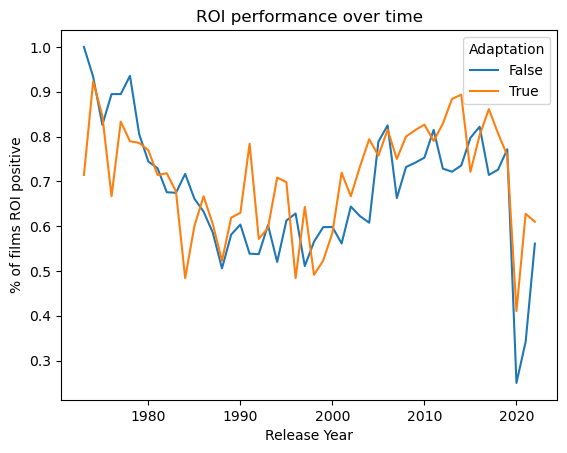

In [106]:
df[
    (~df['new_plot'].isna()) &
    (~df['box_office_clean'].isna()) & (~df['budget_clean'].isna()) &
    (~df['rotten_tomatoes_score'].isna()) &
    (~df['release_date'].isna()) &
    (df['release_year'] <= 2022)
].pivot_table(index = 'release_year', columns = 'based_on_binary', values = 'roi_binary', aggfunc = 'mean').plot()

plt.xlabel('Release Year')
plt.ylabel('% of films ROI positive')
plt.legend(title = 'Adaptation')
plt.title('ROI performance over time')
plt.show()

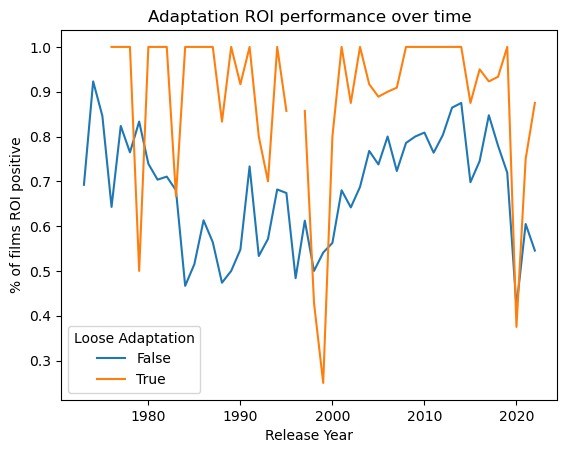

In [107]:
df[
    (~df['new_plot'].isna()) &
    (~df['box_office_clean'].isna()) & (~df['budget_clean'].isna()) &
    (~df['rotten_tomatoes_score'].isna()) &
    (~df['release_date'].isna()) &
    (df['release_year'] <= 2022) &
    (df['based_on_binary'])
].pivot_table(index = 'release_year', columns = 'based_on_binary_characters', values = 'roi_binary', aggfunc = 'mean').plot()

plt.xlabel('Release Year')
plt.ylabel('% of films ROI positive')
plt.legend(title = 'Loose Adaptation')
plt.title('Adaptation ROI performance over time')
plt.show()

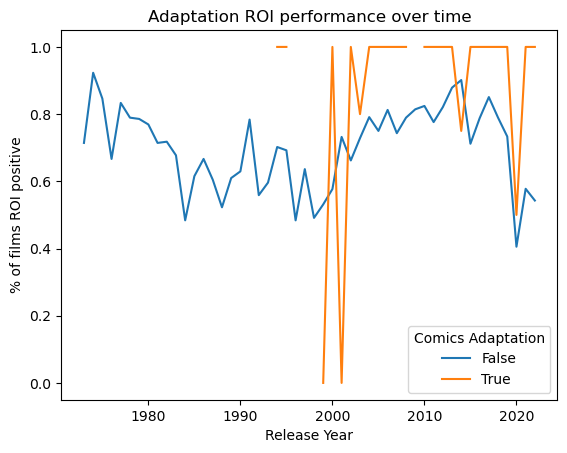

In [108]:
df[
    (~df['new_plot'].isna()) &
    (~df['box_office_clean'].isna()) & (~df['budget_clean'].isna()) &
    (~df['rotten_tomatoes_score'].isna()) &
    (~df['release_date'].isna()) &
    (df['release_year'] <= 2022) &
    (df['based_on_binary'])    
].pivot_table(index = 'release_year', columns = 'based_on_binary_comic_books', values = 'roi_binary', aggfunc = 'mean').plot()

plt.xlabel('Release Year')
plt.ylabel('% of films ROI positive')
plt.legend(title = 'Comics Adaptation')
plt.title('Adaptation ROI performance over time')
plt.show()

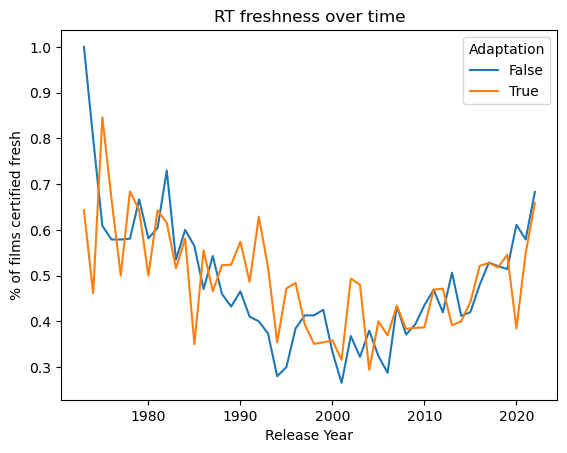

In [109]:
df[
    (~df['new_plot'].isna()) &
    (~df['box_office_clean'].isna()) & (~df['budget_clean'].isna()) &
    (~df['rotten_tomatoes_score'].isna()) &
    (~df['release_date'].isna()) &
    (df['release_year'] <= 2022)    
].pivot_table(index = 'release_year', columns = 'based_on_binary', values = 'rt_binary', aggfunc = 'mean').plot()

plt.xlabel('Release Year')
plt.ylabel('% of films certified fresh')
plt.legend(title = 'Adaptation')
plt.title('RT freshness over time')
plt.show()

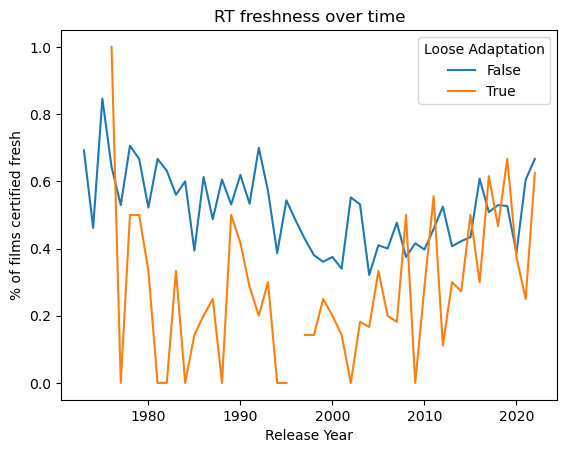

In [110]:
df[
    (~df['new_plot'].isna()) &
    (~df['box_office_clean'].isna()) & (~df['budget_clean'].isna()) &
    (~df['rotten_tomatoes_score'].isna()) &
    (~df['release_date'].isna()) &
    (df['release_year'] <= 2022) &
    (df['based_on_binary'])    
].pivot_table(index = 'release_year', columns = 'based_on_binary_characters', values = 'rt_binary', aggfunc = 'mean').plot()

plt.xlabel('Release Year')
plt.ylabel('% of films certified fresh')
plt.legend(title = 'Loose Adaptation')
plt.title('RT freshness over time')
plt.show()

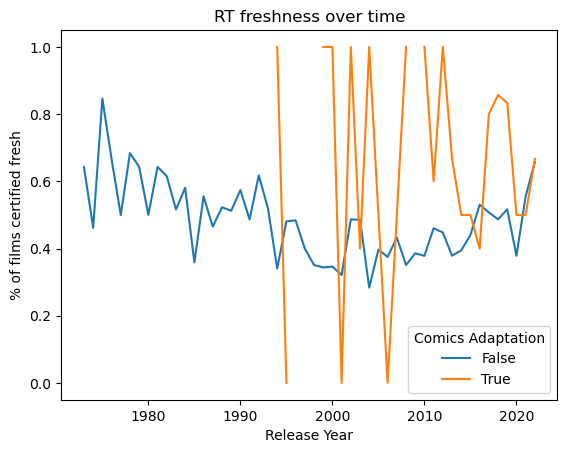

In [111]:
df[
    (~df['new_plot'].isna()) &
    (~df['box_office_clean'].isna()) & (~df['budget_clean'].isna()) &
    (~df['rotten_tomatoes_score'].isna()) &
    (~df['release_date'].isna()) &
    (df['release_year'] <= 2022) &
    (df['based_on_binary'])    
].pivot_table(index = 'release_year', columns = 'based_on_binary_comic_books', values = 'rt_binary', aggfunc = 'mean').plot()

plt.xlabel('Release Year')
plt.ylabel('% of films certified fresh')
plt.legend(title = 'Comics Adaptation')
plt.title('RT freshness over time')
plt.show()